# 1.5. Загрузка и интеграция данных из различных форматов (Лекция_5)

Способы соединения и совмещения данных: объединение таблиц, импорт из CSV/JSON/XML. Обработка ошибок и конфликтов форматов: кодировки, несовместимые типы, пропущенные значения. Инструменты интеграции: Python (pandas), SQL (LOAD DATA), ETL-платформы (например, Pentaho, Talend).



## Задание №1. Соединение данных из нескольких источников (SQL JOIN)

Задача:Есть две таблицы: одна содержит информацию о сотрудниках (Employees), вторая — о департаментах (Departments). Каждая запись в таблице сотрудников ссылается на соответствующий департамент. Объедините обе таблицы, используя SQL JOIN, чтобы получить полную информацию обо всех сотрудниках и их департаментах.

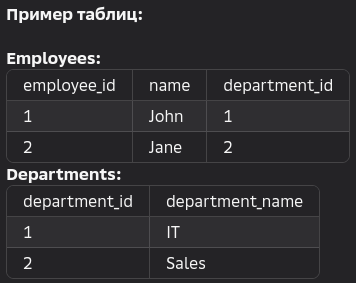

Задание:

In [ ]:
import sqlite3

# Создаем временную базу данных
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# Создаем таблицы
cur.execute("""
CREATE TABLE Employees(
    # Ваш код здесь...
)
""")

cur.execute("""
CREATE TABLE Departments(
    # Ваш код здесь...
)
""")

# Вставляем данные
employees_data = [(1, 'John', 1), (2, 'Jane', 2)]
departments_data = [(1, 'IT'), (2, 'Sales')]

cur.executemany("# Ваш код здесь...", employees_data)
cur.executemany("# Ваш код здесь...", departments_data)

# Запрашиваем объединённые данные
cur.execute("""
# Ваш код здесь...
""")

# Выводим результат
results = cur.fetchall()
for result in results:
    print(result)

# Закрываем подключение
conn.close()

Решение:

In [ ]:
import sqlite3

# Создаем временную базу данных
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# Создаем таблицы
cur.execute("""
CREATE TABLE Employees(
    employee_id INT PRIMARY KEY,
    name TEXT,
    department_id INT
)
""")

cur.execute("""
CREATE TABLE Departments(
    department_id INT PRIMARY KEY,
    department_name TEXT
)
""")

# Вставляем данные
employees_data = [(1, 'John', 1), (2, 'Jane', 2)]
departments_data = [(1, 'IT'), (2, 'Sales')]

cur.executemany("INSERT INTO Employees VALUES (?,?,?)", employees_data)
cur.executemany("INSERT INTO Departments VALUES (?,?)", departments_data)

# Запрашиваем объединённые данные
cur.execute("""
SELECT Employees.name, Departments.department_name
FROM Employees
LEFT JOIN Departments ON Employees.department_id = Departments.department_id
""")

# Выводим результат
results = cur.fetchall()
for result in results:
    print(result)

# Закрываем подключение
conn.close()

('John', 'IT')
('Jane', 'Sales')


---------------------------------------------------------------

## Задание №2. Слияние данных из CSV и JSON

Вам даны два файла: один в формате CSV с информацией о продуктовых складах (warehouses.csv), другой в формате JSON с товарами (products.json). Оба файла имеют общий ключ warehouse_id. Слейте данные таким образом, чтобы каждый склад содержал информацию о находящихся там товарах.

warehouses.csv:

In [ ]:
warehouse_id,location
1,Moscow
2,Saint Petersburg
3,Voronezh

products.json:

In [ ]:
[
    {"product_id": 1, "warehouse_id": 1, "product_name": "Chair"},
    {"product_id": 2, "warehouse_id": 2, "product_name": "Table"},
    {"product_id": 3, "warehouse_id": 1, "product_name": "Desk"}
]

Задание:

In [ ]:
import pandas as pd
import json

# Шаг 1: Создаем файлы с данными

# Создаем CSV-файл с данными о складах
with open('warehouses.csv', 'w') as f:
# Здесь ваш код...

# Создаем JSON-файл с данными о товарах
with open('products.json', 'w') as f:
    json.dump([
# Здесь ваш код...
    ], f)

# Шаг 2: Загружаем данные из CSV и JSON
warehouses = pd.read_csv('warehouses.csv')

# Загружаем данные из JSON
with open('products.json', 'r') as f:
    products = json.load(f)

# Приводим данные к DataFrame
products_df = pd.DataFrame.from_records(products)

# Шаг 3: Производим слияние
merged_data = warehouses.merge(# Здесь ваш код...)

# Шаг 4: Выводим результат
print(merged_data)

Решение:

In [ ]:
import pandas as pd
import json

# Шаг 1: Создаем файлы с данными

# Создаем CSV-файл с данными о складах
with open('warehouses.csv', 'w') as f:
    f.write('warehouse_id,location\n')
    f.write('1,Moscow\n')
    f.write('2,Saint Petersburg\n')
    f.write('3,Voronezh\n')

# Создаем JSON-файл с данными о товарах
with open('products.json', 'w') as f:
    json.dump([
        {"product_id": 1, "warehouse_id": 1, "product_name": "Chair"},
        {"product_id": 2, "warehouse_id": 2, "product_name": "Table"},
        {"product_id": 3, "warehouse_id": 1, "product_name": "Desk"}
    ], f)

# Шаг 2: Загружаем данные из CSV и JSON
warehouses = pd.read_csv('warehouses.csv')

# Загружаем данные из JSON
with open('products.json', 'r') as f:
    products = json.load(f)

# Приводим данные к DataFrame
products_df = pd.DataFrame.from_records(products)

# Шаг 3: Производим слияние
merged_data = warehouses.merge(products_df, left_on='warehouse_id', right_on='warehouse_id', how='inner')

# Шаг 4: Выводим результат
print(merged_data)

   warehouse_id          location  product_id product_name
0             1            Moscow           1        Chair
1             1            Moscow           3         Desk
2             2  Saint Petersburg           2        Table


---------------------------------------------------------------

## Задание №3: Добавление новых записей и фильтрация по условию

Создать временные базы данных, заполнить их необходимыми таблицами и добавить дополнительные записи сотрудников и отделов. Затем выбрать всех сотрудников, работающих в определенном отделе, используя условие WHERE.


Задание:

In [ ]:
import sqlite3

# Создаем временную базу данных
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# Создаем таблицы
cur.execute("""
CREATE TABLE Employees(
    employee_id INT PRIMARY KEY,
    name TEXT,
    salary REAL,
    department_id INT
)
""")

cur.execute("""
CREATE TABLE Departments(
    department_id INT PRIMARY KEY,
    department_name TEXT
)
""")

# Вставляем начальные данные
employees_data = [
    (1, 'Иван Петров', 50000, 1),
    (2, 'Анна Смирнова', 70000, 2),
]
departments_data = [
    (1, 'Отдел IT'),
    (2, 'Продажи')
]

cur.executemany(#Ваш код здесь)
cur.executemany(#Ваш код здесь)

# Добавляем новые записи
new_employees = [
    (3, 'Михаил Иванов', 80000, 1),
    (4, 'Ольга Васильева', 60000, 2)
]
cur.executemany(#Ваш код здесь)

# Запрашиваем всех сотрудников отдела продаж (department_id=2)
cur.execute("""
#Ваш код здесь
""", (2,))

# Выводим результат
results = cur.fetchall()
for row in results:
    print(row)

# Закрываем соединение
conn.close()

Решение:

In [ ]:
import sqlite3

# Создаем временную базу данных
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# Создаем таблицы
cur.execute("""
CREATE TABLE Employees(
    employee_id INT PRIMARY KEY,
    name TEXT,
    salary REAL,
    department_id INT
)
""")

cur.execute("""
CREATE TABLE Departments(
    department_id INT PRIMARY KEY,
    department_name TEXT
)
""")

# Вставляем начальные данные
employees_data = [
    (1, 'Иван Петров', 50000, 1),
    (2, 'Анна Смирнова', 70000, 2),
]
departments_data = [
    (1, 'Отдел IT'),
    (2, 'Продажи')
]

cur.executemany("INSERT INTO Employees VALUES (?,?,?,?)", employees_data)
cur.executemany("INSERT INTO Departments VALUES (?,?)", departments_data)

# Добавляем новые записи
new_employees = [
    (3, 'Михаил Иванов', 80000, 1),
    (4, 'Ольга Васильева', 60000, 2)
]
cur.executemany("INSERT INTO Employees VALUES (?,?,?,?)", new_employees)

# Запрашиваем всех сотрудников отдела продаж (department_id=2)
cur.execute("""
SELECT Employees.employee_id, Employees.name, Employees.salary, Departments.department_name
FROM Employees
JOIN Departments ON Employees.department_id = Departments.department_id
WHERE Departments.department_id = ?
""", (2,))

# Выводим результат
results = cur.fetchall()
for row in results:
    print(row)

# Закрываем соединение
conn.close()

(2, 'Анна Смирнова', 70000.0, 'Продажи')
(4, 'Ольга Васильева', 60000.0, 'Продажи')


------------------------------------------------------------

## Задание №4: Обновление зарплаты сотрудника и группировка по отделам

Создать таблицу сотрудников и департаментов, обновить зарплату конкретного сотрудника, вывести среднее значение зарплат по каждому департаменту.


Задание:

In [ ]:
import sqlite3

# Создаем временную базу данных
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# Создаем таблицы
cur.execute("""
# Ваш код здесь
)
""")

cur.execute("""
# Ваш код здесь
)
""")

# Вставляем данные
employees_data = [
    (1, 'Игорь Кузнецов', 50000, 1),
    (2, 'Светлана Петрова', 70000, 2),
    (3, 'Дмитрий Сергеев', 60000, 1),
    (4, 'Елена Иванова', 80000, 2)
]
departments_data = [
    (1, 'Финансовый отдел'),
    (2, 'Маркетинг')
]

cur.executemany(# Ваш код здесь)
cur.executemany(# Ваш код здесь)

# Повышаем зарплату сотруднику Дмитрий Сергееву на 10%
cur.execute("UPDATE Employees SET salary = salary * 1.1 WHERE name='Дмитрий Сергеев'")

# Выбираем среднюю зарплату по каждому отделу
cur.execute("""
# Ваш код здесь
""")

# Выводим результат
results = cur.fetchall()
for row in results:
    print(f'Средняя зарплата {row[0]} — {round(row[1], 2)} рублей.')

# Закрываем соединение
conn.close()

Решение:

In [ ]:
import sqlite3

# Создаем временную базу данных
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# Создаем таблицы
cur.execute("""
CREATE TABLE Employees(
    employee_id INT PRIMARY KEY,
    name TEXT,
    salary REAL,
    department_id INT
)
""")

cur.execute("""
CREATE TABLE Departments(
    department_id INT PRIMARY KEY,
    department_name TEXT
)
""")

# Вставляем данные
employees_data = [
    (1, 'Игорь Кузнецов', 50000, 1),
    (2, 'Светлана Петрова', 70000, 2),
    (3, 'Дмитрий Сергеев', 60000, 1),
    (4, 'Елена Иванова', 80000, 2)
]
departments_data = [
    (1, 'Финансовый отдел'),
    (2, 'Маркетинг')
]

cur.executemany("INSERT INTO Employees VALUES (?,?,?,?)", employees_data)
cur.executemany("INSERT INTO Departments VALUES (?,?)", departments_data)

# Повышаем зарплату сотруднику Дмитрий Сергееву на 10%
cur.execute("UPDATE Employees SET salary = salary * 1.1 WHERE name='Дмитрий Сергеев'")

# Выбираем среднюю зарплату по каждому отделу
cur.execute("""
SELECT Departments.department_name, AVG(Employees.salary)
FROM Employees
JOIN Departments ON Employees.department_id = Departments.department_id
GROUP BY Departments.department_id
""")

# Выводим результат
results = cur.fetchall()
for row in results:
    print(f'Средняя зарплата {row[0]} — {round(row[1], 2)} рублей.')

# Закрываем соединение
conn.close()

Средняя зарплата Финансовый отдел — 58000.0 рублей.
Средняя зарплата Маркетинг — 75000.0 рублей.


-----------------------------------------------------------------------

## Задание №5: Удаление сотрудника и получение итоговых сумм по отделам

Создай две таблицы: сотрудники и отделы. Удали одного сотрудника и выведи общую сумму зарплат каждого отдела после удаления.

Задание:

In [ ]:
import sqlite3

# Создаем временную базу данных
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# Создаем таблицы
cur.execute("""
# Ваш код здесь
)
""")

cur.execute("""
# Ваш код здесь
)
""")

# Вставляем данные
employees_data = [
    (1, 'Алексей Семенов', 50000, 1),
    (2, 'Евгений Александров', 70000, 2),
    (3, 'Владимир Новиков', 60000, 1),
    (4, 'Дарья Андреева', 80000, 2)
]
departments_data = [
    (1, 'HR-отдел'),
    (2, 'Логистика')
]

cur.executemany(# Ваш код здесь)
cur.executemany(# Ваш код здесь)

# Удаляем сотрудника Евгения Александрова
cur.execute("DELETE FROM Employees WHERE name='Евгений Александров'")

# Получаем итоговую сумму зарплат по каждому отделу
cur.execute("""
# Ваш код здесь
""")

# Выводим результат
results = cur.fetchall()
for row in results:
    print(f'Общая сумма зарплат в {row[0]} — {round(row[1], 2)} рублей.')

# Закрываем соединение
conn.close()

Решение:

In [ ]:
import sqlite3

# Создаем временную базу данных
conn = sqlite3.connect(':memory:')
cur = conn.cursor()

# Создаем таблицы
cur.execute("""
CREATE TABLE Employees(
    employee_id INT PRIMARY KEY,
    name TEXT,
    salary REAL,
    department_id INT
)
""")

cur.execute("""
CREATE TABLE Departments(
    department_id INT PRIMARY KEY,
    department_name TEXT
)
""")

# Вставляем данные
employees_data = [
    (1, 'Алексей Семенов', 50000, 1),
    (2, 'Евгений Александров', 70000, 2),
    (3, 'Владимир Новиков', 60000, 1),
    (4, 'Дарья Андреева', 80000, 2)
]
departments_data = [
    (1, 'HR-отдел'),
    (2, 'Логистика')
]

cur.executemany("INSERT INTO Employees VALUES (?,?,?,?)", employees_data)
cur.executemany("INSERT INTO Departments VALUES (?,?)", departments_data)

# Удаляем сотрудника Евгения Александрова
cur.execute("DELETE FROM Employees WHERE name='Евгений Александров'")

# Получаем итоговую сумму зарплат по каждому отделу
cur.execute("""
SELECT Departments.department_name, SUM(Employees.salary)
FROM Employees
JOIN Departments ON Employees.department_id = Departments.department_id
GROUP BY Departments.department_id
""")

# Выводим результат
results = cur.fetchall()
for row in results:
    print(f'Общая сумма зарплат в {row[0]} — {round(row[1], 2)} рублей.')

# Закрываем соединение
conn.close()

Общая сумма зарплат в HR-отдел — 110000.0 рублей.
Общая сумма зарплат в Логистика — 80000.0 рублей.
